# ECOS Catalog Analysis
Ultrasonic characterisation and density measurements of PVA hydrogel phantoms.

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ecos_loader lives next to this notebook
sys.path.insert(0, str(Path().resolve()))
import ecos_loader

fig_dir = Path('figures')
fig_dir.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
})

base_dir = Path('../database')
df = ecos_loader.build_catalog(base_dir)

for col in ('pva_pct', 'pg_pct', 'cycle'):
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Shape: {df.shape}')
print('Conditions:')
df[['pva_pct', 'pg_pct']].drop_duplicates().sort_values(['pva_pct', 'pg_pct'])

[scan_database] loaded 60 US, 60 DENS
Shape: (60, 25)
Conditions:


,pva_pct,pg_pct
0,10,0
15,10,5
5,10,10
10,10,15
40,15,0
55,15,5
45,15,10
50,15,15
20,125,0
35,125,5


## 2. Summary Table — Mean ± Std by Condition

In [3]:
metrics = ['US_Cl', 'DENS_density_gcm3', 'Z', 'M_GPa']
col_labels = {
    'US_Cl':             'Cl (m/s)',
    'DENS_density_gcm3': 'density (g/cm³)',
    'Z':                 'Z (Rayl)',
    'M_GPa':             'M (GPa)',
}

summary = df.groupby(['pva_pct', 'pg_pct'])[metrics].agg(['mean', 'std', 'count']).round(4)
summary.index.names = ['PVA (%)', 'PG (%)']
summary.columns = pd.MultiIndex.from_tuples(
    [(col_labels[m], s) for m, s in summary.columns],
    names=['Metric', 'Stat'],
)
summary

Metric          Cl (m/s)               density (g/cm³)                \
Stat                mean     std count            mean     std count   
PVA (%) PG (%)                                                         
10      0       1610.510  4.7705     5          0.9803  0.0230     5   
        5       1609.604  4.0579     5          0.9964  0.0461     5   
        10      1606.592  2.8352     5          0.9560  0.0154     5   
        15      1615.614  1.2990     5          0.9515  0.0115     5   
15      0       1626.340  3.8620     5          1.0125  0.0082     5   
        5       1625.494  2.1449     5          0.9688  0.0293     5   
        10      1626.470  3.0009     5          0.9550  0.0205     5   
        15      1633.636  7.0610     5          0.9740  0.0005     5   
125     0       1617.602  3.4363     5          0.9905  0.0192     5   
        5       1611.836  1.8014     5          0.9980  0.0441     5   
        10      1626.552  1.8215     5          0.9805  0.0143     5   
        15      1624.946  3.1666     5          0.9643  0.0103     5   

Metric           Z (Rayl)                   M (GPa)                
Stat                 mean         std count    mean     std count  
PVA (%) PG (%)                                                     
10      0       1578862.8  38147.7125     5  2.5428  0.0641     5  
        5       1603712.0  72380.1987     5  2.5813  0.1140     5  
        10      1535830.4  24267.5224     5  2.4675  0.0388     5  
        15      1537284.2  18065.8120     5  2.4836  0.0285     5  
15      0       1646673.8  14545.1682     5  2.6781  0.0270     5  
        5       1574800.6  48503.8616     5  2.5599  0.0805     5  
        10      1553247.6  35434.6035     5  2.5264  0.0611     5  
        15      1591224.6   6249.3004     5  2.5995  0.0214     5  
125     0       1602255.4  32563.4809     5  2.5918  0.0555     5  
        5       1608581.0  71158.7142     5  2.5928  0.1148     5  
        10      1594783.0  24440.9744     5  2.5940  0.0419     5  
        15      1566990.8  19507.2091     5  2.5463  0.0362     5

## 3. Boxplot: Longitudinal Sound Speed by Condition

C:\Users\Alberto\AppData\Local\Temp\ipykernel_28428\3166730333.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_cl, labels=labels, patch_artist=True)


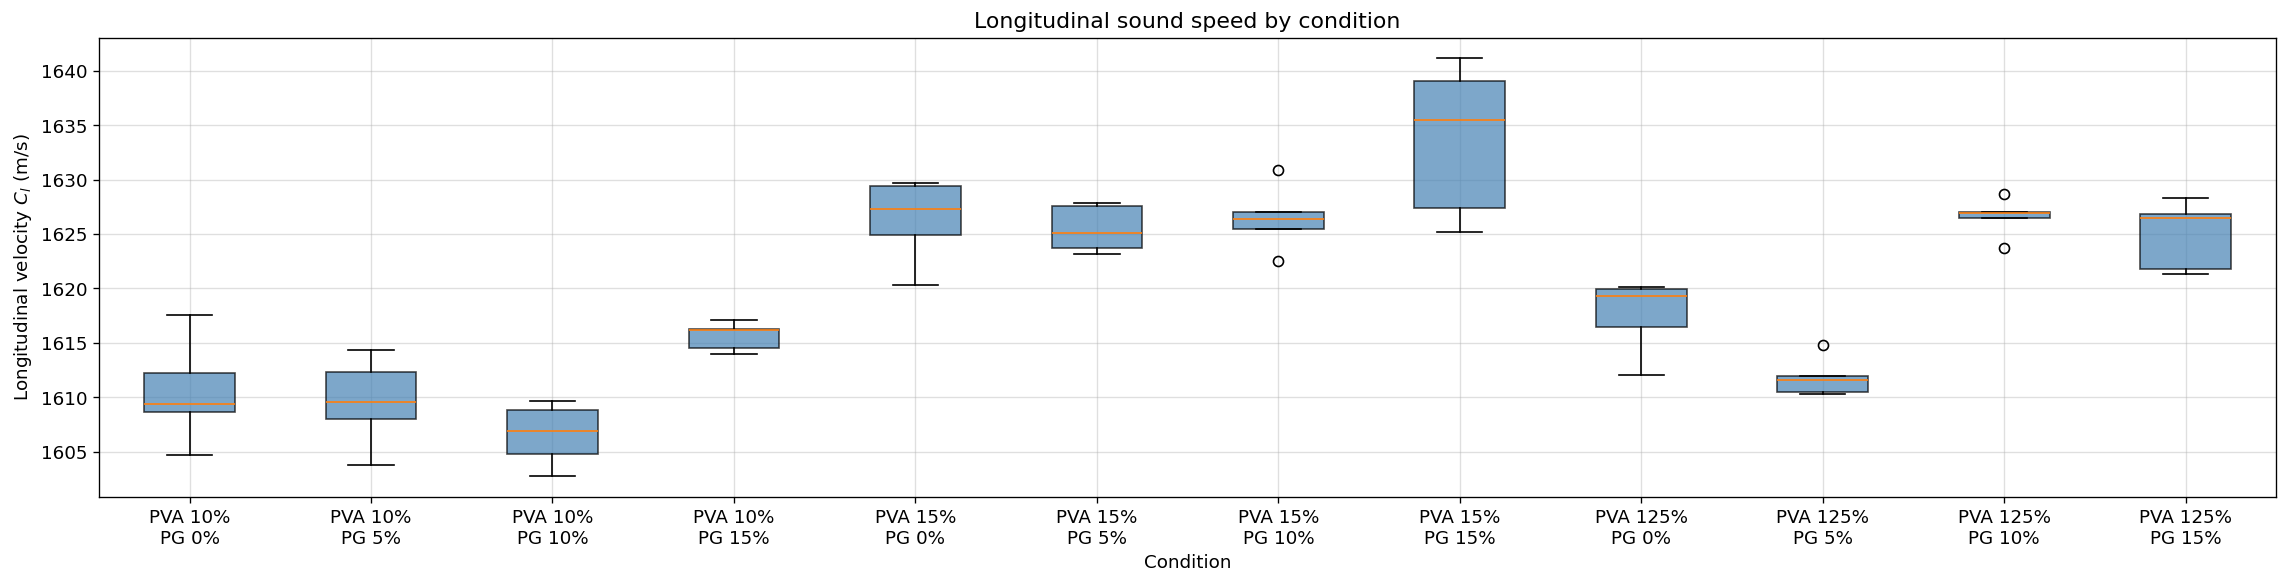

In [4]:
conditions = (
    df[['pva_pct', 'pg_pct']]
    .drop_duplicates()
    .sort_values(['pva_pct', 'pg_pct'])
    .reset_index(drop=True)
)
labels = [
    f'PVA {int(r.pva_pct)}%\nPG {int(r.pg_pct)}%'
    for _, r in conditions.iterrows()
]
data_cl = [
    df[(df['pva_pct'] == r.pva_pct) & (df['pg_pct'] == r.pg_pct)]['US_Cl'].dropna().values
    for _, r in conditions.iterrows()
]

fig, ax = plt.subplots(figsize=(max(6, len(labels) * 1.6), 5))
bp = ax.boxplot(data_cl, labels=labels, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
ax.set_xlabel('Condition')
ax.set_ylabel('Longitudinal velocity $C_l$ (m/s)')
ax.set_title('Longitudinal sound speed by condition')
plt.tight_layout()
plt.savefig(fig_dir / 'boxplot_Cl.png', dpi=150, bbox_inches='tight')
plt.show()

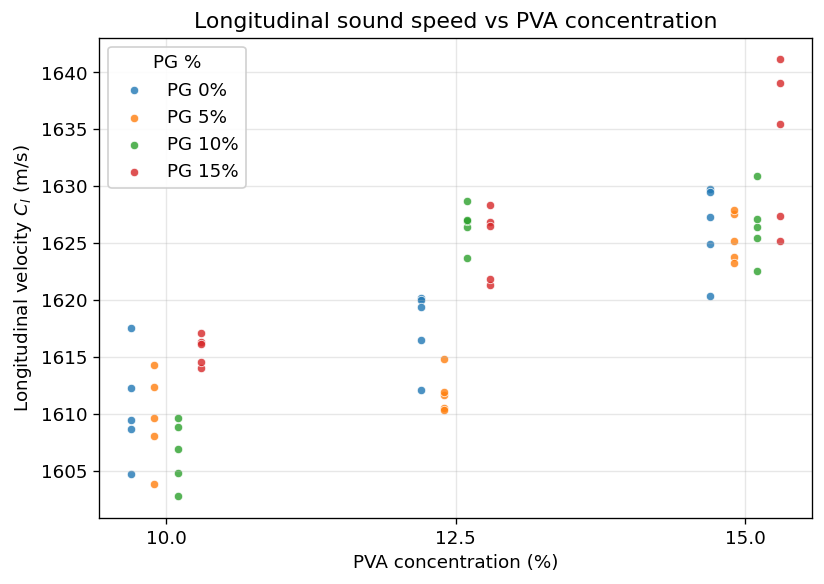

In [8]:
# --- Cl vs PVA%, colored by PG% (jittered) ---
df["pva_real"] = df["pva_pct"].apply(lambda x: x / 10 if x > 100 else x)

fig, ax = plt.subplots(figsize=(7, 5))

pg_levels = sorted(df["pg_pct"].dropna().unique())
n_pg = len(pg_levels)
offsets = np.linspace(-0.3, 0.3, n_pg)  # horizontal spread
cmap = plt.cm.tab10
pg_colors = {pg: cmap(i) for i, pg in enumerate(pg_levels)}

for pg, dx in zip(pg_levels, offsets):
    sub = df[df["pg_pct"] == pg]
    ax.scatter(sub["pva_real"] + dx, sub["US_Cl"],
               color=pg_colors[pg], s=25, alpha=0.8,
               edgecolors="white", linewidths=0.5,
               label=f'PG {int(pg)}%')

ax.set_xticks([10, 12.5, 15])
ax.set_xlabel('PVA concentration (%)')
ax.set_ylabel('Longitudinal velocity $C_l$ (m/s)')
ax.set_title('Longitudinal sound speed vs PVA concentration')
ax.legend(title='PG %', framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / 'scatter_Cl_vs_PVA_by_PG.png', dpi=150, bbox_inches='tight')
plt.show()

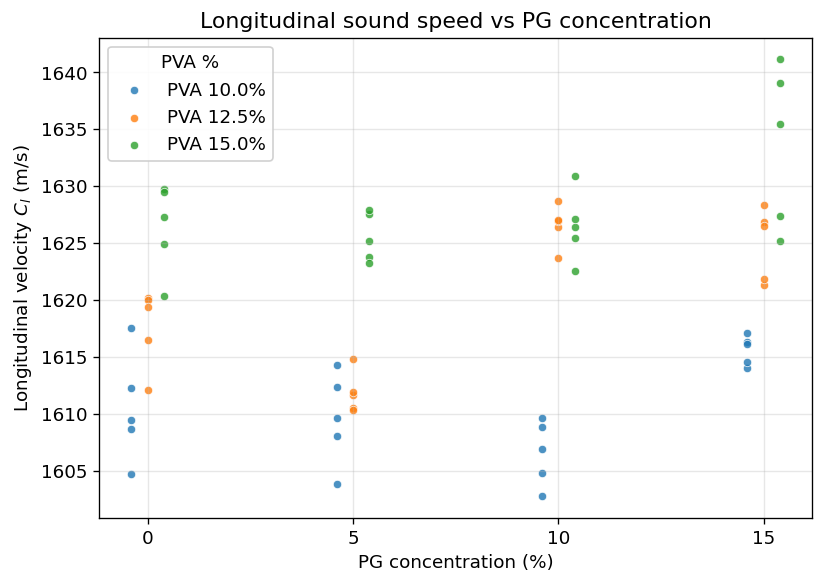

In [9]:
# --- Cl vs PG%, colored by PVA% (jittered) ---
fig, ax = plt.subplots(figsize=(7, 5))

pva_levels = sorted(df["pva_real"].dropna().unique())
n_pva = len(pva_levels)
offsets = np.linspace(-0.4, 0.4, n_pva)
cmap = plt.cm.tab10
pva_colors = {pva: cmap(i) for i, pva in enumerate(pva_levels)}

for pva, dx in zip(pva_levels, offsets):
    sub = df[df["pva_real"] == pva]
    ax.scatter(sub["pg_pct"] + dx, sub["US_Cl"],
               color=pva_colors[pva], s=25, alpha=0.8,
               edgecolors="white", linewidths=0.5,
               label=f'PVA {pva}%')

ax.set_xticks(sorted(df["pg_pct"].dropna().unique()))
ax.set_xlabel('PG concentration (%)')
ax.set_ylabel('Longitudinal velocity $C_l$ (m/s)')
ax.set_title('Longitudinal sound speed vs PG concentration')
ax.legend(title='PVA %', framealpha=0.9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig(fig_dir / 'scatter_Cl_vs_PG_by_PVA.png', dpi=150, bbox_inches='tight')
plt.show()

Cl = 3.48·PVA + 0.48·PG + 1572.5
R² = 0.7226
PVA effect: slope = 3.48 m/s per %, partial r = 0.834, p = 0.0000
PG  effect: slope = 0.48 m/s per %, partial r = 0.495, p = 0.0001


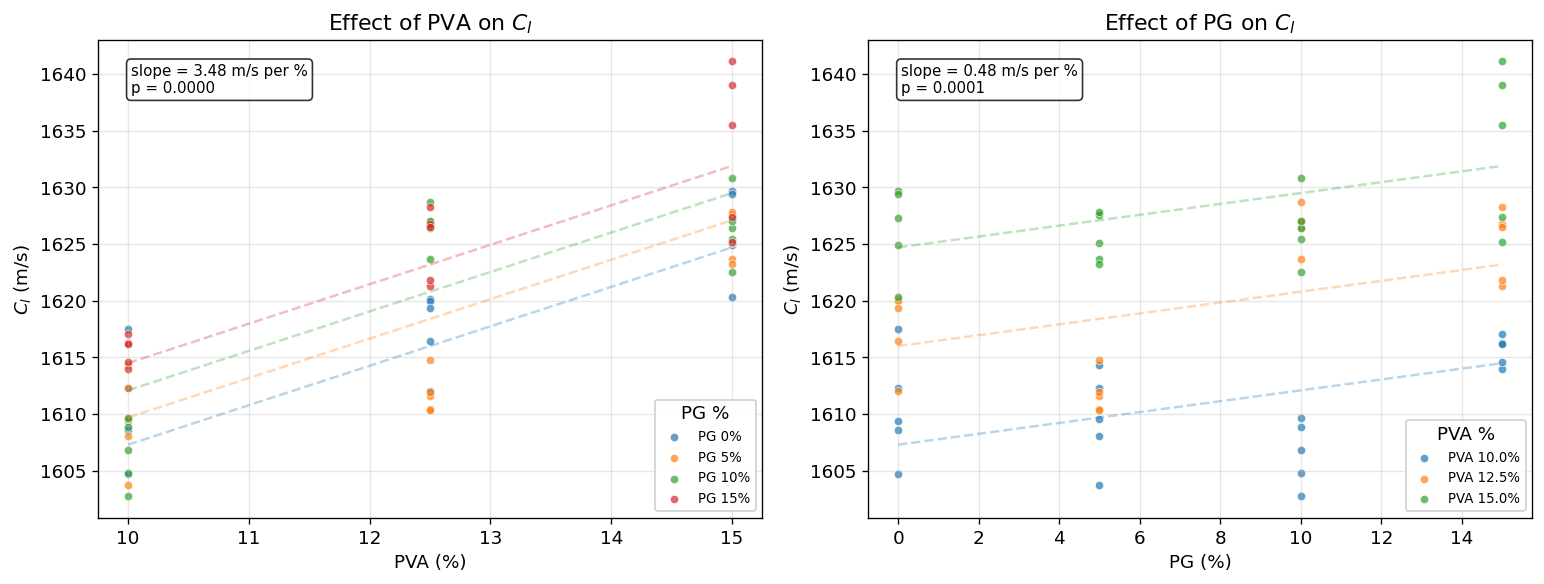

In [14]:
# --- Multiple regression: Cl = a·PVA + b·PG + c ---
from scipy import stats
import numpy as np

mask = df["US_Cl"].notna()
PVA = df.loc[mask, "pva_real"].values
PG  = df.loc[mask, "pg_pct"].values
Cl  = df.loc[mask, "US_Cl"].values

# Fit: Cl = a*PVA + b*PG + c
X = np.column_stack([PVA, PG, np.ones(len(PVA))])
(a, b, c), residuals, rank, sv = np.linalg.lstsq(X, Cl, rcond=None)

Cl_pred = a * PVA + b * PG + c
SS_res = np.sum((Cl - Cl_pred)**2)
SS_tot = np.sum((Cl - Cl.mean())**2)
R2 = 1 - SS_res / SS_tot

# Partial correlations (effect of each factor removing the other)
r_pva_partial, p_pva = stats.pearsonr(Cl - b * PG, PVA)
r_pg_partial, p_pg   = stats.pearsonr(Cl - a * PVA, PG)

print(f"Cl = {a:.2f}·PVA + {b:.2f}·PG + {c:.1f}")
print(f"R² = {R2:.4f}")
print(f"PVA effect: slope = {a:.2f} m/s per %, partial r = {r_pva_partial:.3f}, p = {p_pva:.4f}")
print(f"PG  effect: slope = {b:.2f} m/s per %, partial r = {r_pg_partial:.3f}, p = {p_pg:.4f}")

# --- Two subplots: partial effects ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: Cl adjusted for PG vs PVA
Cl_adj_pg = Cl - b * PG  # remove PG effect
for pg in sorted(df.loc[mask, "pg_pct"].unique()):
    m = PG == pg
    ax1.scatter(PVA[m], Cl[m], s=25, alpha=0.7,
                edgecolors="white", linewidths=0.5, label=f'PG {int(pg)}%')
pva_range = np.linspace(PVA.min(), PVA.max(), 50)
for pg_val in sorted(df.loc[mask, "pg_pct"].unique()):
    ax1.plot(pva_range, a * pva_range + b * pg_val + c, '--', alpha=0.3)
ax1.text(0.05, 0.95, f'slope = {a:.2f} m/s per %\np = {p_pva:.4f}',
         transform=ax1.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax1.set_xlabel('PVA (%)')
ax1.set_ylabel('$C_l$ (m/s)')
ax1.set_title('Effect of PVA on $C_l$')
ax1.legend(title='PG %', fontsize=8, framealpha=0.9)
ax1.grid(True, alpha=0.3)

# Right: Cl vs PG
for pva in sorted(df.loc[mask, "pva_real"].unique()):
    m = PVA == pva
    ax2.scatter(PG[m], Cl[m], s=25, alpha=0.7,
                edgecolors="white", linewidths=0.5, label=f'PVA {pva}%')
pg_range = np.linspace(PG.min(), PG.max(), 50)
for pva_val in sorted(df.loc[mask, "pva_real"].unique()):
    ax2.plot(pg_range, a * pva_val + b * pg_range + c, '--', alpha=0.3)
ax2.text(0.05, 0.95, f'slope = {b:.2f} m/s per %\np = {p_pg:.4f}',
         transform=ax2.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax2.set_xlabel('PG (%)')
ax2.set_ylabel('$C_l$ (m/s)')
ax2.set_title('Effect of PG on $C_l$')
ax2.legend(title='PVA %', fontsize=8, framealpha=0.9)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.savefig(fig_dir / 'Cl_regression_PVA_PG.png', dpi=150, bbox_inches='tight')
plt.show()

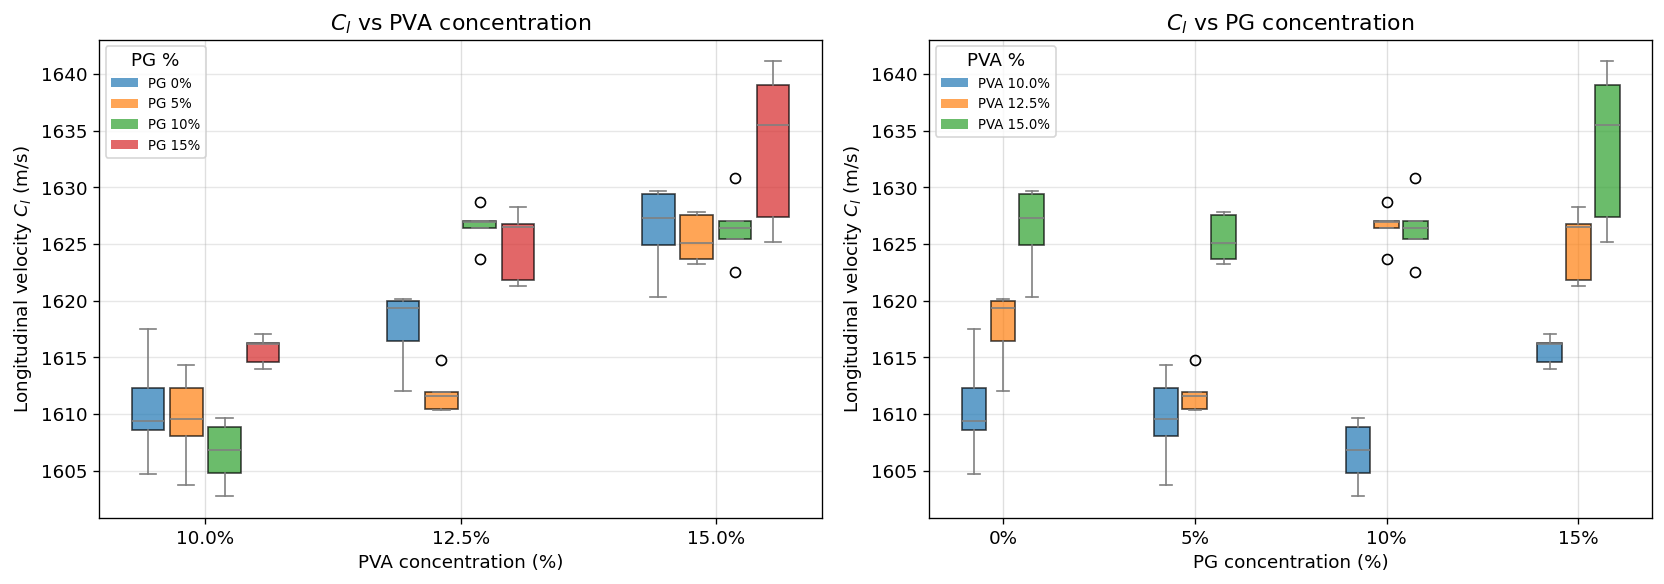

In [15]:
# --- Grouped boxplots: Cl vs PVA (by PG) and Cl vs PG (by PVA) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cmap = plt.cm.tab10

# --- Left: Cl vs PVA%, grouped by PG% ---
pva_levels = sorted(df["pva_real"].dropna().unique())
pg_levels = sorted(df["pg_pct"].dropna().unique())
n_pg = len(pg_levels)
width = 0.15
offsets = np.linspace(-(n_pg-1)/2 * width, (n_pg-1)/2 * width, n_pg)

for i, pg in enumerate(pg_levels):
    data = [df[(df["pva_real"] == pva) & (df["pg_pct"] == pg)]["US_Cl"].dropna().values
            for pva in pva_levels]
    positions = np.array(range(len(pva_levels))) + offsets[i]
    bp = ax1.boxplot(data, positions=positions, widths=width * 0.85,
                     patch_artist=True, manage_ticks=False)
    for patch in bp["boxes"]:
        patch.set_facecolor(cmap(i))
        patch.set_alpha(0.7)
    for element in ["whiskers", "caps", "medians"]:
        for line in bp[element]:
            line.set_color("grey")

ax1.set_xticks(range(len(pva_levels)))
ax1.set_xticklabels([f'{v}%' for v in pva_levels])
ax1.set_xlabel('PVA concentration (%)')
ax1.set_ylabel('Longitudinal velocity $C_l$ (m/s)')
ax1.set_title('$C_l$ vs PVA concentration')
ax1.legend([plt.Rectangle((0,0),1,1, fc=cmap(i), alpha=0.7) for i in range(n_pg)],
           [f'PG {int(pg)}%' for pg in pg_levels], title='PG %', fontsize=8)
ax1.grid(True, alpha=0.3, axis='y')

# --- Right: Cl vs PG%, grouped by PVA% ---
n_pva = len(pva_levels)
offsets2 = np.linspace(-(n_pva-1)/2 * width, (n_pva-1)/2 * width, n_pva)

for i, pva in enumerate(pva_levels):
    data = [df[(df["pg_pct"] == pg) & (df["pva_real"] == pva)]["US_Cl"].dropna().values
            for pg in pg_levels]
    positions = np.array(range(len(pg_levels))) + offsets2[i]
    bp = ax2.boxplot(data, positions=positions, widths=width * 0.85,
                     patch_artist=True, manage_ticks=False)
    for patch in bp["boxes"]:
        patch.set_facecolor(cmap(i))
        patch.set_alpha(0.7)
    for element in ["whiskers", "caps", "medians"]:
        for line in bp[element]:
            line.set_color("grey")

ax2.set_xticks(range(len(pg_levels)))
ax2.set_xticklabels([f'{int(v)}%' for v in pg_levels])
ax2.set_xlabel('PG concentration (%)')
ax2.set_ylabel('Longitudinal velocity $C_l$ (m/s)')
ax2.set_title('$C_l$ vs PG concentration')
ax2.legend([plt.Rectangle((0,0),1,1, fc=cmap(i), alpha=0.7) for i in range(n_pva)],
           [f'PVA {v}%' for v in pva_levels], title='PVA %', fontsize=8)
ax2.grid(True, alpha=0.3, axis='y')

fig.tight_layout()
plt.savefig(fig_dir / 'boxplot_Cl_grouped.png', dpi=150, bbox_inches='tight')
plt.show()

Pearson r = -0.0412,  p-value = 0.7548
R² = 0.0017
→ No statistically significant correlation (p ≥ 0.05)


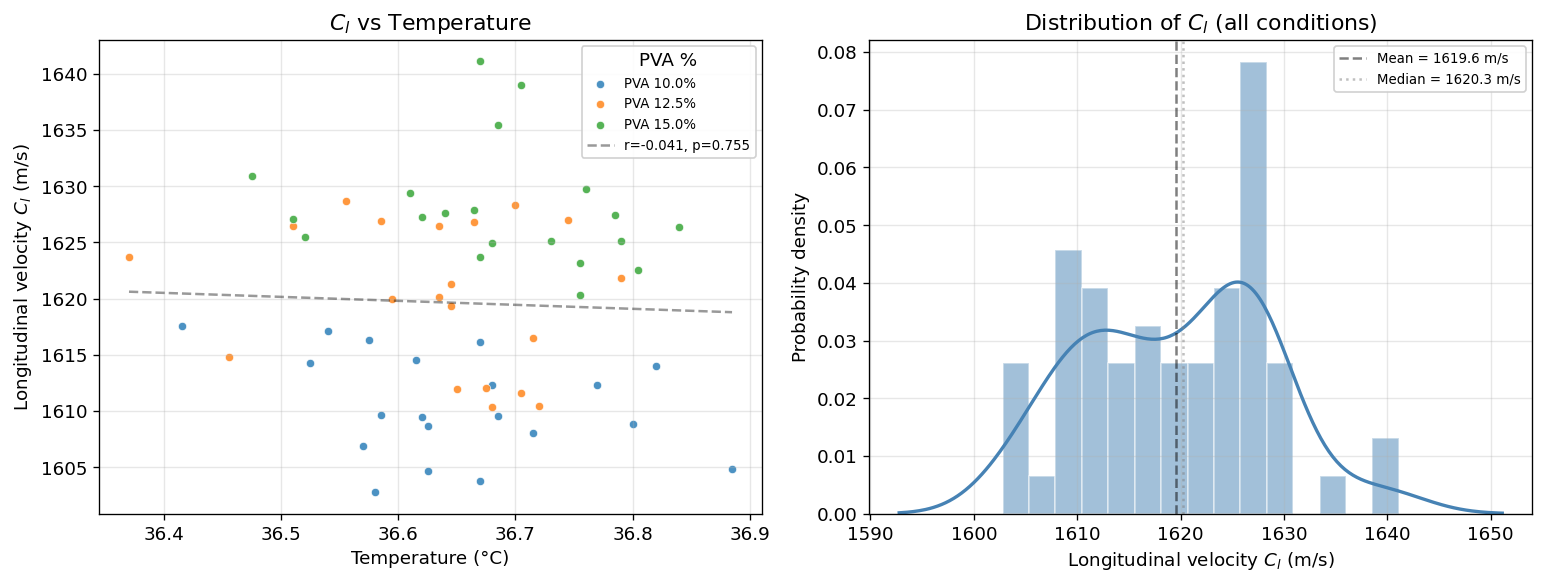

In [16]:
# --- Cl vs Temperature + PDF ---
from scipy import stats

df["US_T_mean"] = (df["US_T1"] + df["US_T2"]) / 2
mask = df["US_Cl"].notna() & df["US_T_mean"].notna()
T = df.loc[mask, "US_T_mean"]
Cl = df.loc[mask, "US_Cl"]

# Pearson correlation
r, p_value = stats.pearsonr(T, Cl)
slope, intercept = np.polyfit(T, Cl, 1)
print(f"Pearson r = {r:.4f},  p-value = {p_value:.4f}")
print(f"R² = {r**2:.4f}")

if p_value < 0.05:
    print("→ Statistically significant correlation (p < 0.05)")
else:
    print("→ No statistically significant correlation (p ≥ 0.05)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: scatter + regression ---
pva_levels = sorted(df["pva_real"].dropna().unique())
cmap = plt.cm.tab10
pva_colors = {pva: cmap(i) for i, pva in enumerate(pva_levels)}

for pva in pva_levels:
    sub = df[df["pva_real"] == pva]
    ax1.scatter(sub["US_T_mean"], sub["US_Cl"],
                color=pva_colors[pva], s=25, alpha=0.8,
                edgecolors="white", linewidths=0.5,
                label=f'PVA {pva}%')

T_range = np.linspace(T.min(), T.max(), 100)
ax1.plot(T_range, slope * T_range + intercept, 'k--', alpha=0.4,
         label=f'r={r:.3f}, p={p_value:.3f}')
ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('Longitudinal velocity $C_l$ (m/s)')
ax1.set_title('$C_l$ vs Temperature')
ax1.legend(title='PVA %', framealpha=0.9, fontsize=8)
ax1.grid(True, alpha=0.3)

# --- Right: PDF of Cl ---
Cl_all = df["US_Cl"].dropna()
kde_x = np.linspace(Cl_all.min() - 10, Cl_all.max() + 10, 300)
kde = stats.gaussian_kde(Cl_all)

ax2.hist(Cl_all, bins=15, density=True, color='steelblue', alpha=0.5, edgecolor='white')
ax2.plot(kde_x, kde(kde_x), color='steelblue', linewidth=2)
ax2.axvline(Cl_all.mean(), color='k', linestyle='--', alpha=0.5,
            label=f'Mean = {Cl_all.mean():.1f} m/s')
ax2.axvline(Cl_all.median(), color='grey', linestyle=':', alpha=0.5,
            label=f'Median = {Cl_all.median():.1f} m/s')
ax2.set_xlabel('Longitudinal velocity $C_l$ (m/s)')
ax2.set_ylabel('Probability density')
ax2.set_title('Distribution of $C_l$ (all conditions)')
ax2.legend(fontsize=8, framealpha=0.9)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.savefig(fig_dir / 'Cl_vs_T_and_PDF.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Boxplot: Density by Condition

C:\Users\Alberto\AppData\Local\Temp\ipykernel_28428\1628138261.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_dens, labels=labels, patch_artist=True)


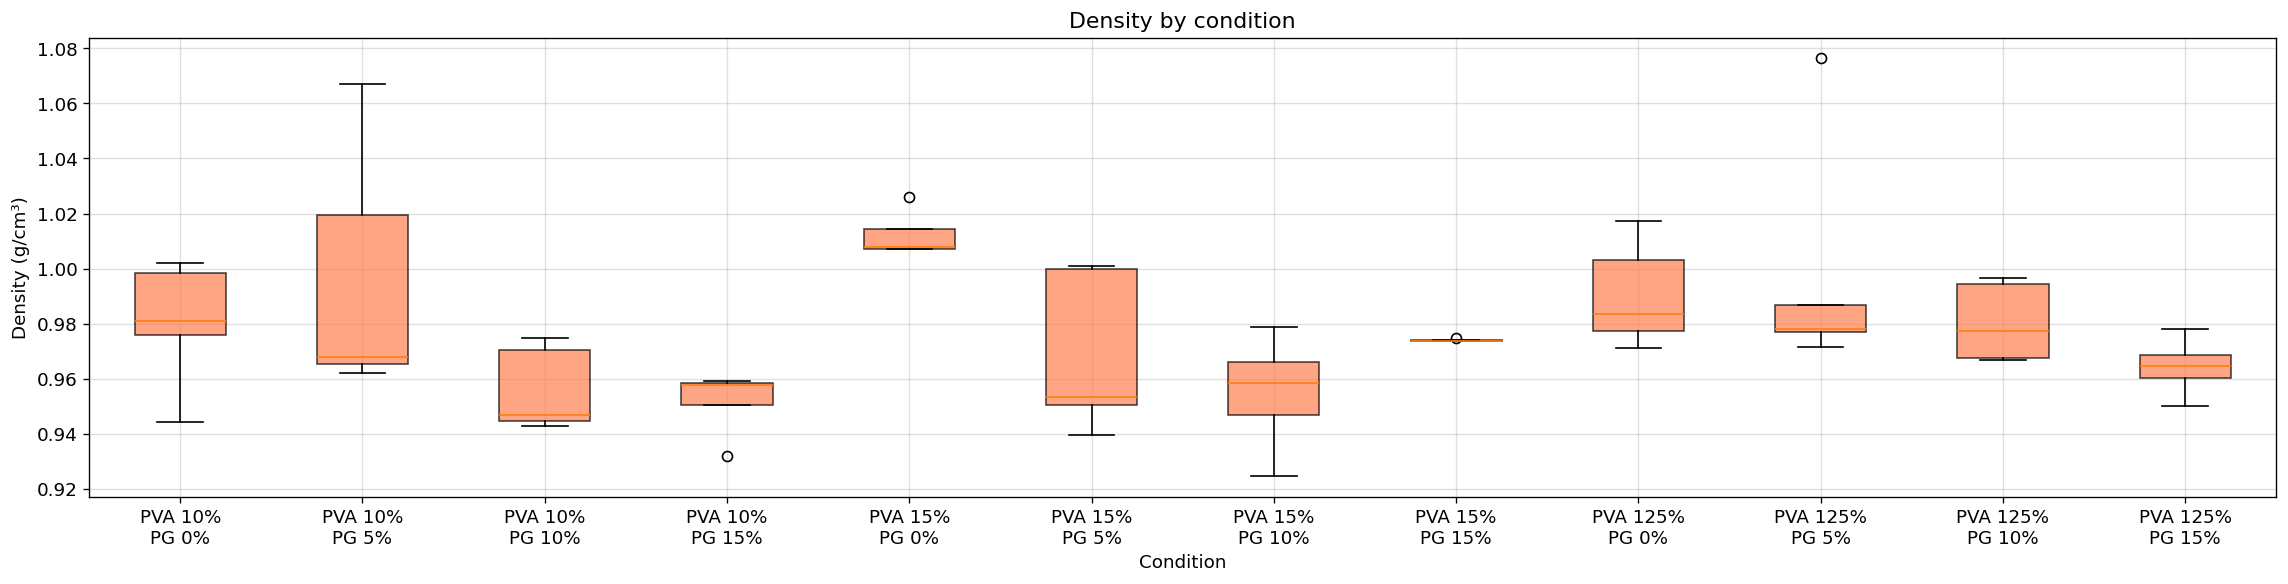

In [17]:
data_dens = [
    df[(df['pva_pct'] == r.pva_pct) & (df['pg_pct'] == r.pg_pct)]['DENS_density_gcm3'].dropna().values
    for _, r in conditions.iterrows()
]

fig, ax = plt.subplots(figsize=(max(6, len(labels) * 1.6), 5))
bp = ax.boxplot(data_dens, labels=labels, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('coral')
    patch.set_alpha(0.7)
ax.set_xlabel('Condition')
ax.set_ylabel('Density (g/cm³)')
ax.set_title('Density by condition')
plt.tight_layout()
plt.savefig(fig_dir / 'boxplot_density.png', dpi=150, bbox_inches='tight')
plt.show()

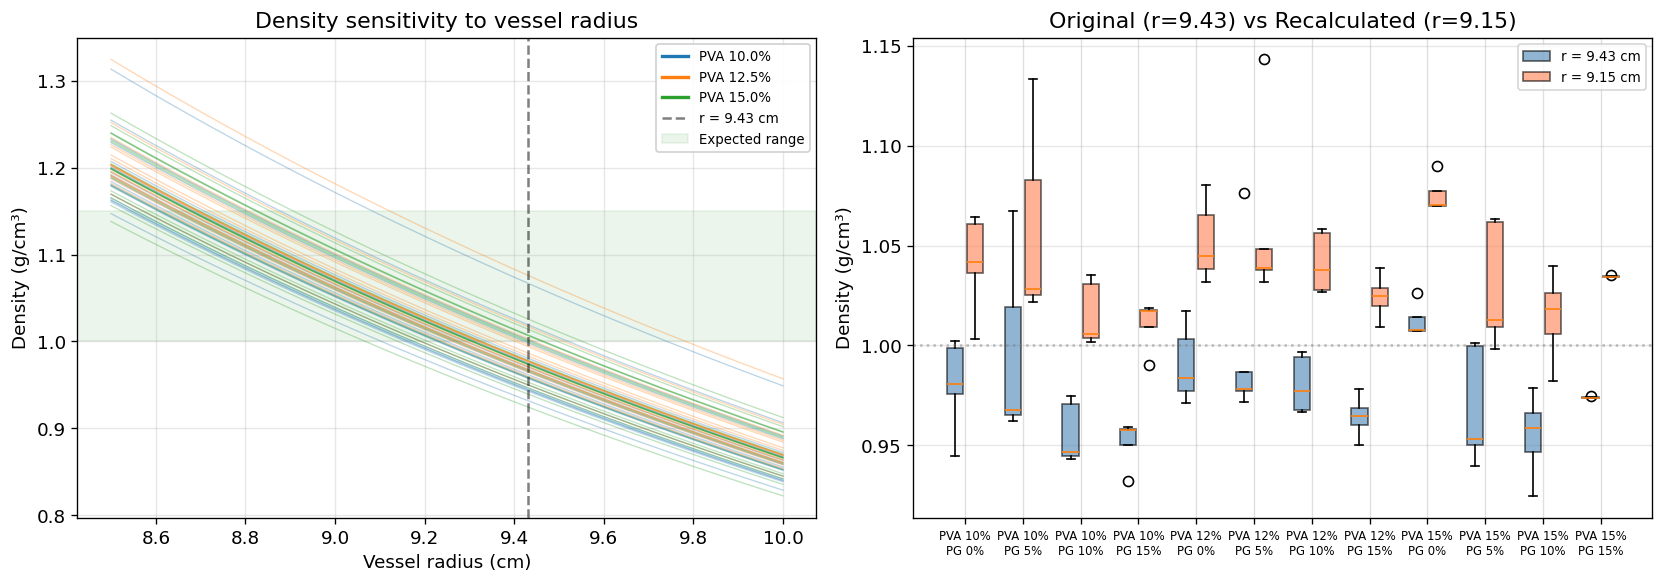


--- Stats with r = 9.15 cm ---
                   mean     std
pva_real pg_pct                
10.0     0       1.0413  0.0244
         5       1.0583  0.0489
         10      1.0154  0.0163
         15      1.0107  0.0122
12.5     0       1.0520  0.0204
         5       1.0600  0.0469
         10      1.0414  0.0152
         15      1.0242  0.0110
15.0     0       1.0754  0.0087
         5       1.0290  0.0311
         10      1.0143  0.0218
         15      1.0346  0.0005


In [22]:
# --- Density recalculation as a function of vessel radius ---
import numpy as np
import matplotlib.pyplot as plt

# Original radius from measurements
r_original = df["DENS_r_vessel_cm"].dropna().iloc[0]

# Recalculate density for a range of radii
radii = np.linspace(8.5, 10.0, 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: density vs radius for each specimen ---
pva_levels = sorted(df["pva_real"].dropna().unique())
cmap = plt.cm.tab10

for i, pva in enumerate(pva_levels):
    sub = df[df["pva_real"] == pva]
    for _, row in sub.iterrows():
        mass = row["DENS_mass_g"]
        dh = row["DENS_delta_h_cm"]
        if np.isnan(mass) or np.isnan(dh) or dh == 0:
            continue
        rho = mass / (np.pi * radii**2 * dh)
        ax1.plot(radii, rho, color=cmap(i), alpha=0.3, linewidth=0.8)

# Legend entries
for i, pva in enumerate(pva_levels):
    ax1.plot([], [], color=cmap(i), linewidth=2, label=f'PVA {pva}%')

ax1.axvline(r_original, color='k', linestyle='--', alpha=0.5, label=f'r = {r_original} cm')
ax1.axhspan(1.0, 1.15, color='green', alpha=0.08, label='Expected range')
ax1.set_xlabel('Vessel radius (cm)')
ax1.set_ylabel('Density (g/cm³)')
ax1.set_title('Density sensitivity to vessel radius')
ax1.legend(fontsize=8, framealpha=0.9)
ax1.grid(True, alpha=0.3)

# --- Right: boxplot of recalculated density for a specific radius ---
def recalc_density(df, r_new):
    dh = df["DENS_delta_h_cm"]
    mass = df["DENS_mass_g"]
    return mass / (np.pi * r_new**2 * dh)

# Try a corrected radius
r_test = 9.15  # <-- ADJUST THIS VALUE
df["DENS_density_recalc"] = recalc_density(df, r_test)

conditions = (
    df[['pva_real', 'pg_pct']].drop_duplicates()
    .sort_values(['pva_real', 'pg_pct']).reset_index(drop=True)
)
labels = [f'PVA {int(r.pva_real)}%\nPG {int(r.pg_pct)}%'
          for _, r in conditions.iterrows()]
data_orig = [
    df[(df['pva_real'] == r.pva_real) & (df['pg_pct'] == r.pg_pct)]['DENS_density_gcm3'].dropna().values
    for _, r in conditions.iterrows()
]
data_recalc = [
    df[(df['pva_real'] == r.pva_real) & (df['pg_pct'] == r.pg_pct)]['DENS_density_recalc'].dropna().values
    for _, r in conditions.iterrows()
]

x = np.arange(len(labels))
w = 0.35
bp1 = ax2.boxplot(data_orig, positions=x - w/2, widths=w*0.8,
                   patch_artist=True, manage_ticks=False)
bp2 = ax2.boxplot(data_recalc, positions=x + w/2, widths=w*0.8,
                   patch_artist=True, manage_ticks=False)

for patch in bp1['boxes']:
    patch.set_facecolor('steelblue'); patch.set_alpha(0.6)
for patch in bp2['boxes']:
    patch.set_facecolor('coral'); patch.set_alpha(0.6)

ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=7)
ax2.set_ylabel('Density (g/cm³)')
ax2.set_title(f'Original (r={r_original}) vs Recalculated (r={r_test})')
ax2.legend([bp1['boxes'][0], bp2['boxes'][0]],
           [f'r = {r_original} cm', f'r = {r_test} cm'], fontsize=8)
ax2.axhline(1.0, color='grey', linestyle=':', alpha=0.5)
ax2.grid(True, alpha=0.3, axis='y')

fig.tight_layout()
plt.show()

print(f"\n--- Stats with r = {r_test} cm ---")
print(df.groupby(['pva_real', 'pg_pct'])['DENS_density_recalc'].agg(['mean', 'std']).round(4))

## 5. Sound Speed vs PG Content

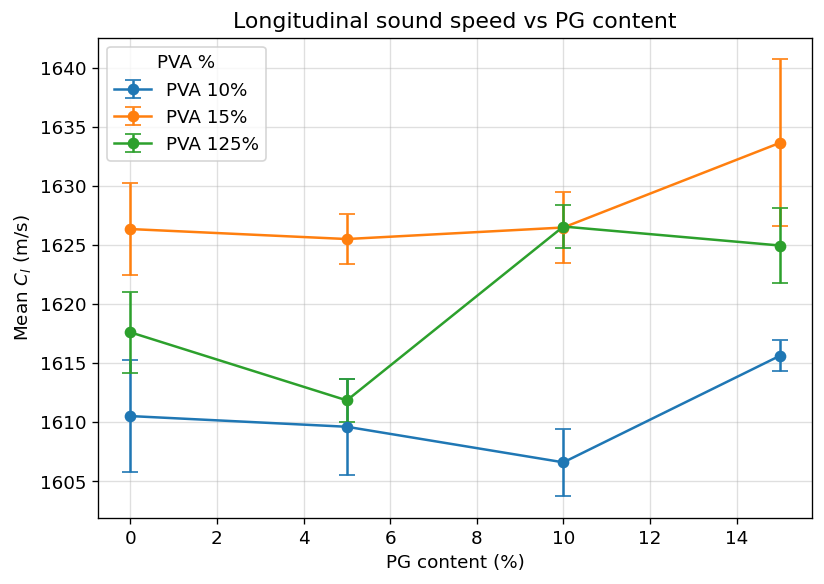

In [23]:
grp_cl = df.groupby(['pva_pct', 'pg_pct']).agg(
    Cl_mean=('US_Cl', 'mean'),
    Cl_std=('US_Cl',  'std'),
).reset_index()

fig, ax = plt.subplots(figsize=(7, 5))
for pva in sorted(grp_cl['pva_pct'].unique()):
    sub = grp_cl[grp_cl['pva_pct'] == pva].sort_values('pg_pct')
    ax.errorbar(
        sub['pg_pct'], sub['Cl_mean'], yerr=sub['Cl_std'],
        marker='o', capsize=5, linewidth=1.5, label=f'PVA {int(pva)}%',
    )
ax.set_xlabel('PG content (%)')
ax.set_ylabel('Mean $C_l$ (m/s)')
ax.set_title('Longitudinal sound speed vs PG content')
ax.legend(title='PVA %')
plt.tight_layout()
plt.savefig(fig_dir / 'lineplot_Cl_vs_PG.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Density vs PG Content

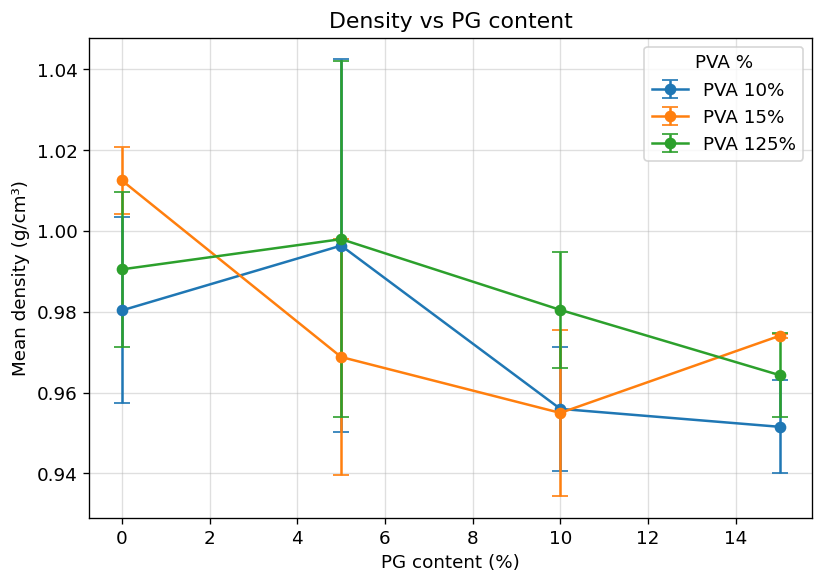

In [24]:
grp_dens = df.groupby(['pva_pct', 'pg_pct']).agg(
    d_mean=('DENS_density_gcm3', 'mean'),
    d_std=('DENS_density_gcm3',  'std'),
).reset_index()

fig, ax = plt.subplots(figsize=(7, 5))
for pva in sorted(grp_dens['pva_pct'].unique()):
    sub = grp_dens[grp_dens['pva_pct'] == pva].sort_values('pg_pct')
    ax.errorbar(
        sub['pg_pct'], sub['d_mean'], yerr=sub['d_std'],
        marker='o', capsize=5, linewidth=1.5, label=f'PVA {int(pva)}%',
    )
ax.set_xlabel('PG content (%)')
ax.set_ylabel('Mean density (g/cm³)')
ax.set_title('Density vs PG content')
ax.legend(title='PVA %')
plt.tight_layout()
plt.savefig(fig_dir / 'lineplot_density_vs_PG.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Sound Speed vs Density

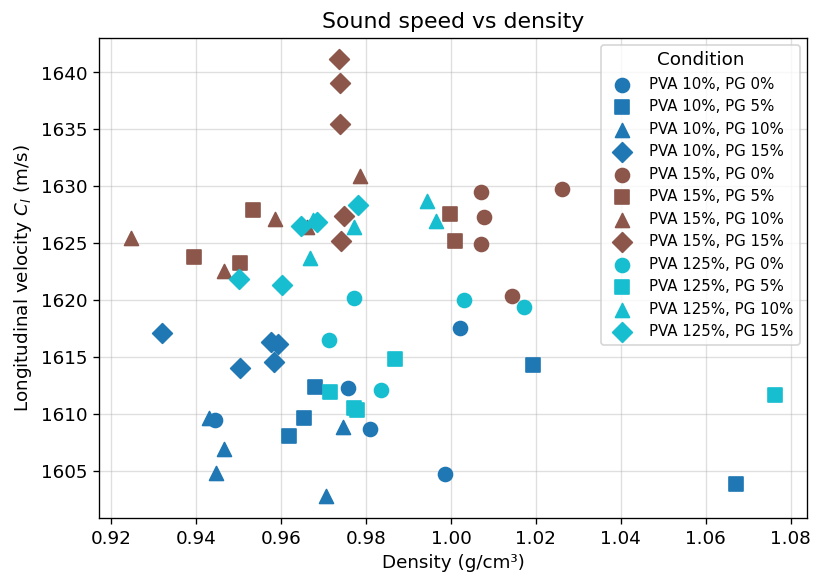

In [25]:
pva_vals = sorted(df['pva_pct'].dropna().unique())
pg_vals  = sorted(df['pg_pct'].dropna().unique())

cmap    = plt.cm.tab10
colors  = {pva: cmap(i / max(len(pva_vals) - 1, 1)) for i, pva in enumerate(pva_vals)}
markers = ['o', 's', '^', 'D', 'v', 'P', '*']
mmap    = {pg: markers[i % len(markers)] for i, pg in enumerate(pg_vals)}

fig, ax = plt.subplots(figsize=(7, 5))
for pva in pva_vals:
    for pg in pg_vals:
        sub = df[(df['pva_pct'] == pva) & (df['pg_pct'] == pg)]
        if sub.empty:
            continue
        ax.scatter(
            sub['DENS_density_gcm3'], sub['US_Cl'],
            color=colors[pva], marker=mmap[pg], s=70, zorder=3,
            label=f'PVA {int(pva)}%, PG {int(pg)}%',
        )
ax.set_xlabel('Density (g/cm³)')
ax.set_ylabel('Longitudinal velocity $C_l$ (m/s)')
ax.set_title('Sound speed vs density')
ax.legend(fontsize=9, title='Condition', loc='best')
plt.tight_layout()
plt.savefig(fig_dir / 'scatter_Cl_vs_density.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Acoustic Impedance and Elastic Modulus by Condition

In [ ]:
grp_zm = df.groupby(['pva_pct', 'pg_pct']).agg(
    Z_mean=('Z',     'mean'), Z_std=('Z',     'std'),
    M_mean=('M_GPa', 'mean'), M_std=('M_GPa', 'std'),
).reset_index()
labels_zm = [
    f'PVA {int(r.pva_pct)}%\nPG {int(r.pg_pct)}%'
    for _, r in grp_zm.iterrows()
]
x = np.arange(len(labels_zm))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax1 = axes[0]
ax1.bar(x, grp_zm['Z_mean'], yerr=grp_zm['Z_std'], color='steelblue', alpha=0.8,
        capsize=5, error_kw={'elinewidth': 1.5})
ax1.set_xticks(x)
ax1.set_xticklabels(labels_zm)
ax1.set_ylabel('Acoustic impedance Z (Rayl)')
ax1.set_title('Acoustic impedance by condition')

ax2 = axes[1]
ax2.bar(x, grp_zm['M_mean'], yerr=grp_zm['M_std'], color='coral', alpha=0.8,
        capsize=5, error_kw={'elinewidth': 1.5})
ax2.set_xticks(x)
ax2.set_xticklabels(labels_zm)
ax2.set_ylabel('Elastic modulus M (GPa)')
ax2.set_title('Longitudinal elastic modulus by condition')

plt.tight_layout()
plt.savefig(fig_dir / 'bar_Z_M.png', dpi=150, bbox_inches='tight')
plt.show()